# 2차 체크포인트 규칙 검증 (`04_Second_Checkpoint`)

```
03_Final_Model_Tiers → [04_Second_Checkpoint] → 05_Intervention_Guide
```

## 목적

25일 1차 등급은 **곧 떠날 학생**은 잘 잡지만(26–32일 이탈자의 90%를 고위험·주의로 포착), **늦게 떠나는 학생의 절반은 25일에 신호가 약해**
관찰·일반 등급에 남는다(`03_Final_Model_Tiers` 7.2절). 이 노트북은 그 학생들을 **25일 이후의 실제 행동으로 다시 점검하는 2차 규칙**을 검증한다.

## 사전 탐색에서 정한 방향 (2026-09-13, 개발 세트 — 3.1절에서 재현)

- **25일 이후 클릭은 신호가 약하다**: 25일 등급이 같은 학생끼리 비교하면 32–60일 누적 클릭·일평균 클릭 비율의 AUC가 0.45–0.58이다.
- **25일 이후 새 평가 미제출은 강한 신호다**: 46일 기준 관찰 등급은 미제출 24.0% vs 제출 10.9%, 일반 등급은 21.4% vs 6.6%다.
- **새 평가 마감일이 과목마다 다르다**: 32일로 고정하면 새 평가가 있는 학생이 8%뿐이다 → **과목별 25일 이후 첫 평가 마감일**을 체크포인트로 삼는다.
- **결과는 관리자에게 전달한다**(학생 통보 없음). 2차는 관리자 명단에 **추가**하는 규칙이다.

## 사전 고정한 판단 원칙

> **승격 원칙**: 25일 등급이 관찰·일반인 학생 중 체크포인트에서 어떤 조건을 만족한 집단의 **실제 이탈률(개발 세트)이 주의 등급 하한 20% 이상**이면,
> 그 집단을 **주의 등급으로 승격**한다.

1차 등급에서 "주의 = 평균 이탈률(20%) 이상이면 관리자 명단"이라고 정의했으므로, 2차 승격도 같은 의미를 유지한다. 판단은 **개발 세트로만** 하고,
규칙을 고정한 뒤 holdout에 한 번 적용한다.

## 용어

- **체크포인트일 `C`**: 과목·학기별로 25일 이후 처음 마감되는 TMA/CMA의 마감일(가중치 무관, `0913_01` 정의와 일관)
- **체크포인트 재학생**: `C`일에도 재학 중인 학생(`date_unregistration`이 없거나 `C`보다 늦음). **이탈 시점은 평가용으로만** 쓴다
- **미제출**: 그 평가를 `C`일까지 제출하지 않음(이월받은 경우는 제출 의무가 없으므로 미제출로 보지 않음)
- **활동 감소**: `(25, C]` 기간 일평균 클릭 ÷ `[0, 25]` 기간 일평균 클릭이 0.5 이하(보조 신호)

## 1. 환경 설정과 데이터

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

INK, INK_2, MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False, 'figure.facecolor': SURFACE,
                     'axes.facecolor': SURFACE, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': GRID, 'text.color': INK_2, 'axes.titlecolor': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED, 'legend.frameon': False})
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
TIER_NAMES = {1: '1 고위험', 2: '2 주의', 3: '3 관찰', 4: '4 일반'}
PROMOTE_MIN_RATE = 0.20   # 주의 등급 하한과 같은 승격 기준
DECLINE_RATIO = 0.5       # 활동 감소 기준


def show(frame, formats=None):
    view = frame.copy()
    for col, f in (formats or {}).items():
        if col in view.columns:
            view[col] = view[col].map(lambda v, f=f: f.format(v) if pd.notna(v) else '')
    display(view)


PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'CSV_files').exists():
    PROJECT_ROOT = (PROJECT_ROOT / '../..').resolve()
CSV_DIR, MODEL_DIR = PROJECT_ROOT / 'CSV_files', PROJECT_ROOT / 'CSV_files' / '모델링'
GRAIN = ['id_student', 'code_module', 'code_presentation']
TARGET = 'target_churn_after_25'

rule = json.load(open(MODEL_DIR / 'final_tier_rule_n25.json', encoding='utf-8'))
clean = pd.read_csv(CSV_DIR / '통합 버전' / 'model_df_clean_n25.csv')
tiers = pd.concat([pd.read_csv(MODEL_DIR / 'final_dev_tiers_n25.csv').assign(세트='개발', proba=lambda d: d['pred_proba_cv']),
                   pd.read_csv(MODEL_DIR / 'final_holdout_tiers_n25.csv').assign(세트='holdout', proba=lambda d: d['pred_proba'])], ignore_index=True)
assessments = pd.read_csv(CSV_DIR / 'assessments.csv')
student_assessment = pd.read_csv(CSV_DIR / 'studentAssessment.csv')

base = tiers[GRAIN + [TARGET, 'proba', 'tier', '세트']].merge(
    clean[GRAIN + ['date_unregistration', 'total_click_25']], on=GRAIN, how='left', validate='one_to_one')
assert len(base) == len(clean) == 27_654
# 취소일은 Withdrawn에만 있어야 하지만, 25일 이후 취소일이 있는 Fail 1건이 원본에 존재한다(07 감사 보고서 4.2절)
print('취소일이 있는 비이탈(타깃 0) 행:', int((base['date_unregistration'].notna() & (base[TARGET] == 0)).sum()))
assert (base.loc[base[TARGET] == 1, 'date_unregistration'].notna()).all(), '모델 대상 이탈자는 모두 25일 이후 취소일이 있어야 함'
print(base.groupby('세트').agg(행=('tier', 'size'), 이탈=(TARGET, 'sum')))
print('1차 등급 기준:', rule['tier_rule'])

취소일이 있는 비이탈(타깃 0) 행: 1
             행    이탈
세트                  
holdout   9150  1720
개발       18504  3526
1차 등급 기준: {'high': 0.4, 'mid': 0.2, 'low': 0.13, 'module_top': 0.3}


## 2. 과목·학기별 체크포인트일과 대상 평가

**왜 보는가**: 체크포인트일이 과목마다 다르면 관리자가 점검하는 시점과 그 전에 떠나는 학생 수가 달라진다. 늦은 체크포인트일수록 그 전에 이탈자가 빠져나간다.

In [2]:
post25 = assessments[assessments['assessment_type'].isin(['TMA', 'CMA']) & (assessments['date'] > 25)]
checkpoint = (post25.sort_values(['code_module', 'code_presentation', 'date', 'id_assessment'])
              .groupby(['code_module', 'code_presentation']).first().reset_index()
              .rename(columns={'date': 'checkpoint_day', 'id_assessment': 'checkpoint_assessment', 'assessment_type': 'checkpoint_type', 'weight': 'checkpoint_weight'}))
# 같은 날 마감되는 평가가 여럿이면 그중 하나라도 미제출이면 미제출로 본다
same_day = post25.merge(checkpoint[['code_module', 'code_presentation', 'checkpoint_day']], on=['code_module', 'code_presentation'])
same_day = same_day[same_day['date'] == same_day['checkpoint_day']]
checkpoint['same_day_n'] = checkpoint.merge(same_day.groupby(['code_module', 'code_presentation']).size().rename('n').reset_index(),
                                            on=['code_module', 'code_presentation'])['n'].to_numpy()

cp = base.merge(checkpoint[['code_module', 'code_presentation', 'checkpoint_day', 'checkpoint_type', 'checkpoint_weight', 'same_day_n']],
                on=['code_module', 'code_presentation'], how='left', validate='many_to_one')
assert cp['checkpoint_day'].notna().all()
cp['enrolled_at_cp'] = cp['date_unregistration'].isna() | (cp['date_unregistration'] > cp['checkpoint_day'])
cp['left_before_cp'] = ~cp['enrolled_at_cp']
print('체크포인트 전 취소자 중 타깃 0(Fail 등):', int((cp['left_before_cp'] & (cp[TARGET] == 0)).sum()))

cp_table = cp.groupby(['code_module', 'code_presentation', '세트']).agg(
    체크포인트일=('checkpoint_day', 'first'), 유형=('checkpoint_type', 'first'), 가중치=('checkpoint_weight', 'first'), 같은날_평가수=('same_day_n', 'first'),
    재학생_25일=('tier', 'size'), 체크포인트_전_이탈=('left_before_cp', 'sum'), 이탈자_25일=(TARGET, 'sum'))
cp_table['이탈자 중 체크포인트 전 이탈'] = cp_table['체크포인트_전_이탈'] / cp_table['이탈자_25일']
show(cp_table.reset_index(), {'체크포인트일': '{:.0f}', '가중치': '{:.0f}', '이탈자 중 체크포인트 전 이탈': '{:.1%}'})

체크포인트 전 취소자 중 타깃 0(Fail 등): 0


,code_module,code_presentation,세트,체크포인트일,유형,가중치,같은날_평가수,재학생_25일,체크포인트_전_이탈,이탈자_25일,이탈자 중 체크포인트 전 이탈
0,AAA,2013J,개발,54,TMA,20,1,370,6,48,12.5%
1,AAA,2014J,holdout,54,TMA,20,1,348,5,49,10.2%
2,BBB,2013B,개발,47,TMA,18,1,1592,104,332,31.3%
3,BBB,2013J,개발,47,TMA,18,1,1835,46,246,18.7%
4,BBB,2014B,개발,40,TMA,18,1,1279,14,159,8.8%
5,BBB,2014J,holdout,54,TMA,10,1,1776,38,234,16.2%
6,CCC,2014B,개발,32,TMA,9,1,1520,47,482,9.8%
7,CCC,2014J,holdout,32,TMA,9,1,2006,64,586,10.9%
8,DDD,2013B,개발,51,CMA,3,1,1179,89,312,28.5%
9,DDD,2013J,개발,53,TMA,12,1,1650,70,397,17.6%


## 3. 체크포인트 신호 계산

- **미제출**: 체크포인트일에 마감되는 평가(같은 날 여럿이면 전부)를 `C`일까지 모두 제출했는지. 이월(`is_banked = 1`)은 제출 의무가 없으므로 제출로 본다.
- **활동 감소**: `studentVle`에서 `(25, C]` 일평균 클릭 ÷ `[0, 25]` 일평균 클릭. 25일까지 클릭이 0인 학생은 비교 기준이 없으므로 `(25, C]` 클릭도 0이면 감소로 본다.

In [3]:
due = same_day[['id_assessment', 'code_module', 'code_presentation', 'checkpoint_day']]
sa = student_assessment.merge(due, on='id_assessment', how='inner')
sa = sa[sa['code_module'].notna()]
done = sa[(sa['is_banked'] == 1) | (sa['date_submitted'] <= sa['checkpoint_day'])]
n_done = done.groupby(GRAIN).size().rename('n_done').reset_index()
cp = cp.merge(n_done, on=GRAIN, how='left')
cp['n_done'] = cp['n_done'].fillna(0)
cp['missed_cp'] = cp['n_done'] < cp['same_day_n']

max_cp = int(cp['checkpoint_day'].max())
parts = []
for chunk in pd.read_csv(CSV_DIR / 'studentVle.csv', chunksize=2_000_000):
    chunk = chunk[(chunk['date'] > 25) & (chunk['date'] <= max_cp)]
    parts.append(chunk.groupby(GRAIN + ['date'])['sum_click'].sum())
daily = pd.concat(parts).groupby(level=[0, 1, 2, 3]).sum().reset_index()
daily = daily.merge(checkpoint[['code_module', 'code_presentation', 'checkpoint_day']], on=['code_module', 'code_presentation'])
post_clicks = daily[daily['date'] <= daily['checkpoint_day']].groupby(GRAIN)['sum_click'].sum().rename('clicks_post').reset_index()
cp = cp.merge(post_clicks, on=GRAIN, how='left')
cp['clicks_post'] = cp['clicks_post'].fillna(0)
cp['rate_ratio'] = (cp['clicks_post'] / (cp['checkpoint_day'] - 25)) / (cp['total_click_25'] / 26).replace(0, np.nan)
cp['activity_decline'] = np.where(cp['total_click_25'] > 0, cp['rate_ratio'] <= DECLINE_RATIO, cp['clicks_post'] == 0)

assert not cp.duplicated(GRAIN).any() and len(cp) == 27_654
e = cp[cp['enrolled_at_cp']]
print('체크포인트 재학생 중 미제출 비율:', e.groupby('세트')['missed_cp'].mean().round(3).to_dict())
print('체크포인트 재학생 중 활동 감소 비율:', e.groupby('세트')['activity_decline'].mean().round(3).to_dict())

체크포인트 재학생 중 미제출 비율: {'holdout': 0.255, '개발': 0.336}
체크포인트 재학생 중 활동 감소 비율: {'holdout': 0.366, '개발': 0.365}


### 3.1 고정 기간과 비교 — 사전 탐색 재현 (개발 세트)

**왜 보는가**: 체크포인트를 과목별 첫 평가 마감일로 정한 근거와, 2차 신호로 클릭을 쓰지 않은 근거를 노트북 안에서 재현한다.
32·39·46·60일로 기간을 고정했을 때 ① 그 전에 떠나는 이탈자 비율, ② 새 평가가 마감된 재학생 비율, ③ 같은 25일 등급 안에서 25일 이후 클릭이 이탈을 구분하는 정도(AUC)를 본다.
AUC는 0.5면 구분력 없음이고, 클릭이 적을수록 위험하다는 방향으로 계산한다.

In [4]:
from sklearn.metrics import roc_auc_score

dev_all = cp[cp['세트'] == '개발']
win_rows, auc_rows = [], []
for W in [32, 39, 46, 60]:
    co = dev_all[~(dev_all['date_unregistration'] <= W)]
    lost = dev_all.loc[dev_all['date_unregistration'] <= W, TARGET].sum() / dev_all[TARGET].sum()
    clicks_w = daily[daily['date'] <= W].groupby(GRAIN)['sum_click'].sum().rename('clicks_w').reset_index()
    co = co.merge(clicks_w, on=GRAIN, how='left').fillna({'clicks_w': 0})
    co['ratio_w'] = (co['clicks_w'] / (W - 25) + 0.1) / (co['total_click_25'] / 26 + 0.1)
    due_w = post25[post25['date'] <= W]
    n_due = due_w.groupby(['code_module', 'code_presentation']).size().rename('n_due').reset_index()
    bk = (student_assessment[(student_assessment['is_banked'] == 1) & student_assessment['id_assessment'].isin(due_w['id_assessment'])]
          .merge(due_w[['id_assessment', 'code_module', 'code_presentation']], on='id_assessment').groupby(GRAIN).size().rename('bk').reset_index())
    co = co.merge(n_due, on=['code_module', 'code_presentation'], how='left').merge(bk, on=GRAIN, how='left').fillna({'n_due': 0, 'bk': 0})
    win_rows.append({'고정 기간 W': W, '재학생': len(co), '그 전에 떠난 이탈자 비율': lost, '새 평가가 마감된 재학생 비율': ((co['n_due'] - co['bk']) > 0).mean()})
    for t, g in co.groupby('tier'):
        auc_rows.append({'W': W, '25일 등급': TIER_NAMES[t], '누적 클릭 AUC': roc_auc_score(g[TARGET], -g['clicks_w']),
                         '일평균 클릭 비율 AUC': roc_auc_score(g[TARGET], -g['ratio_w'])})

show(pd.DataFrame(win_rows).set_index('고정 기간 W'), {'재학생': '{:,}', '그 전에 떠난 이탈자 비율': '{:.1%}', '새 평가가 마감된 재학생 비율': '{:.1%}'})
auc_table = pd.DataFrame(auc_rows).pivot(index='25일 등급', columns='W')
show(auc_table.round(3))
vals = auc_table.to_numpy().ravel()
print(f'같은 등급 안에서 25일 이후 클릭 AUC 범위: {vals.min():.2f}–{vals.max():.2f}')

,재학생,그 전에 떠난 이탈자 비율,새 평가가 마감된 재학생 비율
고정 기간 W,,,
32,"18,183",9.1%,8.1%
39,"18,007",14.1%,16.3%
46,"17,842",18.8%,23.1%
60,"17,516",28.0%,89.1%


누적 클릭 AUC                      일평균 클릭 비율 AUC                     
W             32     39     46     60            32     39     46     60
25일 등급                                                                  
1 고위험      0.491  0.479  0.478  0.446         0.530  0.528  0.534  0.510
2 주의       0.492  0.487  0.492  0.485         0.512  0.511  0.522  0.517
3 관찰       0.510  0.509  0.520  0.520         0.542  0.543  0.565  0.579
4 일반       0.524  0.527  0.525  0.527         0.538  0.551  0.561  0.566

같은 등급 안에서 25일 이후 클릭 AUC 범위: 0.45–0.58


**해석 — 고정 기간으로는 두 문제가 생긴다 (개발 세트)**

| 고정 기간 | 그 전에 떠난 이탈자 | 새 평가가 마감된 재학생 |
|---|---:|---:|
| 32일 | 9.1% | **8.1%** |
| 46일 | 18.8% | 23.1% |
| 60일 | **28.0%** | 89.1% |

- **기간을 앞당기면 신호가 없고, 늦추면 학생이 떠난다.** 32일에는 새 평가가 마감된 학생이 8.1%뿐이라 미제출 신호를 쓸 수 없고,
  60일에는 새 평가가 대부분 마감되지만 이탈자의 28.0%가 이미 떠난 뒤다. → **과목마다 첫 평가가 마감되는 날**을 체크포인트로 삼으면, 신호가 생기는 즉시 점검할 수 있다.
- **25일 이후 클릭은 같은 등급 안에서 이탈을 거의 구분하지 못한다.** 누적 클릭과 일평균 클릭 비율의 AUC가 모든 등급·기간에서 **0.45–0.58**이다(0.5 = 구분력 없음).
  고위험·주의에서는 0.5 아래로 내려가기도 한다. 25일 모델이 이미 활동 정보를 반영했기 때문에, 이후 클릭이 추가로 주는 정보가 적다.
- 이 결과로 2차 신호는 **평가 미제출을 주 신호**로, 활동 감소는 **보조 후보**로만 두고 4절에서 승격 원칙으로 판단한다.

## 4. 승격 후보 집단의 실제 이탈률 (개발 세트) — 승격 원칙 적용

체크포인트 재학생만 대상으로, **25일 등급 × 신호**별 이후 이탈률을 본다. 승격 원칙(이탈률 ≥ 20%)을 만족하는 칸만 승격 대상이 된다.
과목별로도 보되, 과목 단위는 표본이 작아 **판단은 전체 기준으로 하고 과목별은 예외 확인용**으로 쓴다.

In [5]:
dev_e = cp[(cp['세트'] == '개발') & cp['enrolled_at_cp']].copy()
dev_e['신호'] = np.select([dev_e['missed_cp'], dev_e['activity_decline']], ['평가 미제출', '제출 + 활동 감소'], '제출 + 활동 유지')
grid = dev_e.groupby(['tier', '신호'])[TARGET].agg(['size', 'mean']).unstack('신호')
grid.index = grid.index.map(TIER_NAMES)
display(grid.round(3))

cand = dev_e[dev_e['tier'] >= 3]
cand_rows = []
for name, mask in {
    '관찰 × 평가 미제출': (cand['tier'] == 3) & cand['missed_cp'],
    '일반 × 평가 미제출': (cand['tier'] == 4) & cand['missed_cp'],
    '관찰 × 제출 + 활동 감소': (cand['tier'] == 3) & ~cand['missed_cp'] & cand['activity_decline'],
    '일반 × 제출 + 활동 감소': (cand['tier'] == 4) & ~cand['missed_cp'] & cand['activity_decline'],
    '관찰·일반 × 제출 + 활동 유지': ~cand['missed_cp'] & ~cand['activity_decline'],
}.items():
    cand_rows.append({'집단': name, '행 수': int(mask.sum()), '이후 이탈률': cand.loc[mask, TARGET].mean(),
                      '승격 원칙(≥20%)': '충족' if cand.loc[mask, TARGET].mean() >= PROMOTE_MIN_RATE else '미충족'})
cand_table = pd.DataFrame(cand_rows).set_index('집단')
show(cand_table, {'행 수': '{:,}', '이후 이탈률': '{:.1%}'})

by_mod = cand[cand['missed_cp']].groupby(['code_module', 'tier'])[TARGET].agg(['size', 'mean']).unstack('tier')
by_mod.columns = [f'{a}_{TIER_NAMES[b]}' for a, b in by_mod.columns]
print('과목별 관찰·일반 × 평가 미제출의 이후 이탈률 (예외 확인용)')
show(by_mod, {c: '{:.1%}' for c in by_mod.columns if c.startswith('mean')} | {c: '{:,.0f}' for c in by_mod.columns if c.startswith('size')})

size                         mean                  
신호    제출 + 활동 감소 제출 + 활동 유지 평가 미제출 제출 + 활동 감소 제출 + 활동 유지 평가 미제출
tier                                                           
1 고위험         95        321   1327      0.379      0.318  0.408
2 주의         516       1398   2034      0.200      0.210  0.281
3 관찰         817       2431   1377      0.110      0.102  0.211
4 일반        1670       4606   1272      0.075      0.066  0.140

,행 수,이후 이탈률,승격 원칙(≥20%)
집단,,,
관찰 × 평가 미제출,"1,377",21.1%,충족
일반 × 평가 미제출,"1,272",14.0%,미충족
관찰 × 제출 + 활동 감소,817,11.0%,미충족
일반 × 제출 + 활동 감소,"1,670",7.5%,미충족
관찰·일반 × 제출 + 활동 유지,"7,037",7.9%,미충족


과목별 관찰·일반 × 평가 미제출의 이후 이탈률 (예외 확인용)


,size_3 관찰,size_4 일반,mean_3 관찰,mean_4 일반
code_module,,,,
AAA,47,35,23.4%,22.9%
BBB,404,386,21.3%,17.1%
CCC,87,61,18.4%,11.5%
DDD,321,332,19.0%,11.1%
EEE,100,81,30.0%,17.3%
FFF,267,134,26.6%,23.1%
GGG,151,243,9.9%,6.2%


**해석 (개발 세트, 체크포인트 재학생)**

- **평가 미제출은 모든 등급에서 이탈률을 끌어올린다**: 고위험 40.8% / 주의 28.1% / 관찰 21.1% / 일반 14.0%.
  제출하고 활동을 유지한 학생은 같은 등급에서 각각 31.8% / 21.0% / 10.2% / 6.6%다.
- **활동 감소는 제출 여부에 비해 약하다**: 관찰 등급에서 제출 + 활동 감소는 11.0%, 제출 + 활동 유지는 10.2%로 거의 같다(일반 7.5% vs 6.6%).
  사전 탐색의 결론("25일 이후 클릭은 약한 신호")과 같다.
- **승격 원칙(≥ 20%) 적용 결과**
  - 관찰 × 평가 미제출: **21.1% → 충족**
  - 일반 × 평가 미제출: 14.0% → 미충족(평균보다 낮아 관리자 명단에 올릴 근거 부족)
  - 활동 감소 집단: 7.5–11.0% → 미충족
- **과목별 예외 확인**: 관찰 × 미제출은 EEE 30.0%, FFF 26.6%, AAA 23.4%, BBB 21.3%로 원칙을 넘고,
  CCC 18.4%·DDD 19.0%는 경계 부근이다. **GGG는 9.9%로 뚜렷한 예외**다. GGG는 25일 등급의 관찰이 대부분
  "과목 내 상위 30%" 조건으로 들어온 학생이고 개발 학기 GGG 기준 이탈률 자체가 5.9%로 낮아서다(1.7배 수준).
  사전 원칙대로 판단은 전체 기준으로 하고 과목 예외는 한계로 기록한다.
- 사전 탐색(46일 고정 기간)에서 일반 × 미제출이 21.4%였던 것과 달리 여기서 14.0%인 이유는, 과목별 첫 평가 마감일이
  대부분 46일보다 이르거나 늦어 **"미제출"의 범위가 다르기 때문**으로 보인다(고정 기간은 여러 평가가 섞임).

## 5. 2차 규칙 확정 (개발 세트 근거로 고정)

4절 결과로 승격 원칙을 적용해 규칙을 고정한다. 규칙 후보는 아래와 같고, **원칙을 만족한 집단만 포함한 규칙**을 채택한다.
나머지 후보는 디펜스용 비교로 남긴다(6절).

| 후보 | 승격 조건 (체크포인트 재학생, 25일 등급 관찰·일반) |
|---|---|
| R0 | 2차 없음 (1차만) |
| R1 | 관찰 × 평가 미제출 |
| R2 | 관찰·일반 × 평가 미제출 |
| R3 | R2 + 활동 감소(제출했더라도) |
| R4 | 관찰·일반 × 활동 감소만 (평가 정보 미사용) |

In [6]:
RULES = {
    'R0 1차만': lambda d: np.zeros(len(d), dtype=bool),
    'R1 관찰×미제출': lambda d: (d['tier'] == 3) & d['missed_cp'],
    'R2 관찰·일반×미제출': lambda d: (d['tier'] >= 3) & d['missed_cp'],
    'R3 R2+활동감소': lambda d: (d['tier'] >= 3) & (d['missed_cp'] | d['activity_decline']),
    'R4 관찰·일반×활동감소': lambda d: (d['tier'] >= 3) & d['activity_decline'],
}
ok = cand_table['승격 원칙(≥20%)'] == '충족'
use_obs_miss, use_gen_miss = ok['관찰 × 평가 미제출'], ok['일반 × 평가 미제출']
use_decline = ok['관찰 × 제출 + 활동 감소'] and ok['일반 × 제출 + 활동 감소']
if use_obs_miss and use_gen_miss and use_decline:
    CHOSEN = 'R3 R2+활동감소'
elif use_obs_miss and use_gen_miss:
    CHOSEN = 'R2 관찰·일반×미제출'
elif use_obs_miss:
    CHOSEN = 'R1 관찰×미제출'
else:
    CHOSEN = 'R0 1차만'
print('승격 원칙 충족 여부:', ok.to_dict())
print('채택 규칙:', CHOSEN)

승격 원칙 충족 여부: {'관찰 × 평가 미제출': True, '일반 × 평가 미제출': False, '관찰 × 제출 + 활동 감소': False, '일반 × 제출 + 활동 감소': False, '관찰·일반 × 제출 + 활동 유지': False}
채택 규칙: R1 관찰×미제출


## 6. 규칙 비교 — 개발 세트 (디펜스)

**지표 정의** (분모에 주의)

- **관리자 명단 추가 비율**: 2차로 새로 명단에 오르는 학생 ÷ 25일 재학생
- **승격 집단 이탈률**: 새로 명단에 오른 학생 중 실제 이탈 비율(연락의 적중률)
- **체크포인트 이후 이탈자 포착**: 체크포인트 재학생 중 이후 이탈자가 관리자 명단(25일 고위험·주의 또는 2차 승격)에 있는 비율
- **전체 이탈자 포착(1차+2차)**: 25일 재학생 중 이탈자가 25일 명단에 있었거나 체크포인트에서 승격된 비율. 체크포인트 전에 떠난 학생은 25일 명단에 있어야만 포착

In [7]:
def evaluate(frame, promote):
    y = frame[TARGET].to_numpy() == 1
    staff25 = frame['tier'].to_numpy() <= 2
    enrolled = frame['enrolled_at_cp'].to_numpy()
    promote = np.asarray(promote) & enrolled & ~staff25
    after = y & enrolled
    return {
        '관리자 명단(25일)': staff25.mean(),
        '관리자 명단 추가': promote.mean(),
        '관리자 명단 합계': (staff25 | promote).mean(),
        '승격 인원': int(promote.sum()),
        '승격 집단 이탈률': y[promote].mean() if promote.any() else np.nan,
        '체크포인트 이후 이탈자 포착(25일 명단)': (after & staff25).sum() / after.sum(),
        '체크포인트 이후 이탈자 포착(1차+2차)': (after & (staff25 | promote)).sum() / after.sum(),
        '전체 이탈자 포착(25일 명단)': (y & staff25).sum() / y.sum(),
        '전체 이탈자 포착(1차+2차)': (y & (staff25 | promote)).sum() / y.sum(),
    }


dev = cp[cp['세트'] == '개발'].reset_index(drop=True)
rule_dev = pd.DataFrame({k: evaluate(dev, f(dev)) for k, f in RULES.items()}).T
fmt = {c: '{:.1%}' for c in rule_dev.columns if c != '승격 인원'} | {'승격 인원': '{:,.0f}'}
show(rule_dev, fmt)

rows = []
for m in sorted(dev['code_module'].unique()):
    s = dev[dev['code_module'] == m].reset_index(drop=True)
    r = evaluate(s, RULES[CHOSEN](s))
    rows.append({'code_module': m, '체크포인트일': s['checkpoint_day'].iloc[0] if s['checkpoint_day'].nunique() == 1 else f"{s['checkpoint_day'].min():.0f}–{s['checkpoint_day'].max():.0f}",
                 **{k: r[k] for k in ['관리자 명단(25일)', '관리자 명단 추가', '승격 집단 이탈률', '전체 이탈자 포착(25일 명단)', '전체 이탈자 포착(1차+2차)']}})
show(pd.DataFrame(rows).set_index('code_module'), {c: '{:.1%}' for c in ['관리자 명단(25일)', '관리자 명단 추가', '승격 집단 이탈률', '전체 이탈자 포착(25일 명단)', '전체 이탈자 포착(1차+2차)']})

,관리자 명단(25일),관리자 명단 추가,관리자 명단 합계,승격 인원,승격 집단 이탈률,체크포인트 이후 이탈자 포착(25일 명단),체크포인트 이후 이탈자 포착(1차+2차),전체 이탈자 포착(25일 명단),전체 이탈자 포착(1차+2차)
R0 1차만,33.5%,0.0%,33.5%,0,,57.1%,57.1%,61.1%,61.1%
R1 관찰×미제출,33.5%,7.4%,40.9%,"1,377",21.1%,57.1%,67.1%,61.1%,69.3%
R2 관찰·일반×미제출,33.5%,14.3%,47.8%,"2,649",17.7%,57.1%,73.3%,61.1%,74.4%
R3 R2+활동감소,33.5%,27.8%,61.3%,"5,136",13.3%,57.1%,80.8%,61.1%,80.5%
R4 관찰·일반×활동감소,33.5%,20.8%,54.3%,"3,846",12.5%,57.1%,73.7%,61.1%,74.7%


,체크포인트일,관리자 명단(25일),관리자 명단 추가,승격 집단 이탈률,전체 이탈자 포착(25일 명단),전체 이탈자 포착(1차+2차)
code_module,,,,,,
AAA,54.0,21.9%,12.7%,23.4%,39.6%,62.5%
BBB,40–47,25.4%,8.6%,21.3%,47.4%,59.0%
CCC,32.0,70.1%,5.7%,18.4%,88.6%,91.9%
DDD,51–53,52.6%,8.3%,19.0%,77.6%,83.7%
EEE,33.0,15.6%,6.5%,30.0%,28.6%,43.2%
FFF,47–52,33.1%,5.6%,26.6%,55.0%,62.5%
GGG,61.0,0.1%,8.8%,9.9%,0.0%,14.7%


**해석 — 규칙 비교 (개발 세트)**

| 규칙 | 명단 추가 | 명단 합계 | 승격 집단 이탈률 | 전체 이탈자 포착 | 판단 |
|---|---:|---:|---:|---:|---|
| R0 1차만 | 0% | 33.5% | — | 61.1% | 늦은 이탈자 보완 없음 |
| **R1 관찰 × 미제출 (채택)** | **7.4%** | **40.9%** | **21.1%** | **69.3%** | 승격 집단이 주의 기준(20%)을 만족하는 유일한 규칙 |
| R2 관찰·일반 × 미제출 | 14.3% | 47.8% | 17.7% | 74.4% | 추가 인원이 두 배인데 적중률이 평균 이하 |
| R3 R2 + 활동 감소 | 27.8% | 61.3% | 13.3% | 80.5% | 재학생 61%가 명단 → 관리자 과부하, 적중률 낮음 |
| R4 관찰·일반 × 활동 감소 | 20.8% | 54.3% | 12.5% | 74.7% | 평가 정보 없이는 적중률이 가장 낮음 |

- **R1은 관리자 명단을 7.4%p 늘려 이탈자 포착을 61.1% → 69.3%(+8.2%p)로 올린다.** 새로 연락하는 학생 다섯 명 중 한 명 이상이 실제 이탈 학생이다.
- R2·R3는 포착률을 더 올리지만 **추가 명단의 적중률이 전체 평균(19%) 이하**라, "평균보다 위험하면 명단"이라는 1차 등급의 의미가 깨지고 관리자 부담이 급증한다.
- **과목별**: EEE는 25일 명단이 이탈자의 28.6%만 잡았는데 2차로 43.2%까지 오른다(+14.6%p). 평가가 33일에 있어 체크포인트가 빠르고 미제출 신호가 강하다.
  AAA +22.9%p, BBB +11.6%p도 크다. GGG는 0% → 14.7%로 오르지만 적중률이 9.9%로 낮다(4절 예외).

## 7. 이탈 시점별 포착 — 2차가 늦은 이탈자를 보완하는가 (개발 세트)

In [8]:
def timing(frame, promote):
    y = frame[TARGET].to_numpy() == 1
    staff25 = frame['tier'].to_numpy() <= 2
    promote = np.asarray(promote) & frame['enrolled_at_cp'].to_numpy() & ~staff25
    pos = frame[y].assign(명단25=staff25[y], 승격=promote[y])
    pos['이탈 시점'] = pd.cut(pos['date_unregistration'], [25, 32, 60, 120, 1000], labels=['26–32일', '33–60일', '61–120일', '121일+'])
    t = pos.groupby('이탈 시점', observed=True).agg(이탈자=('명단25', 'size'), 명단25=('명단25', 'mean'), 승격_추가=('승격', 'mean'))
    t['1차+2차'] = t['명단25'] + t['승격_추가']
    return t


timing_dev = timing(dev, RULES[CHOSEN](dev))
show(timing_dev, {'이탈자': '{:,}', '명단25': '{:.1%}', '승격_추가': '{:.1%}', '1차+2차': '{:.1%}'})

,이탈자,명단25,승격_추가,1차+2차
이탈 시점,,,,
26–32일,321,89.7%,0.0%,89.7%
33–60일,667,72.0%,6.6%,78.6%
61–120일,"1,026",57.2%,10.7%,67.9%
121일+,"1,512",52.8%,9.0%,61.8%


## 8. holdout(2014J) 적용 — 규칙 고정 후 1회

holdout: 체크포인트 재학생의 등급 × 신호별 이후 이탈률


size                         mean                  
신호    제출 + 활동 감소 제출 + 활동 유지 평가 미제출 제출 + 활동 감소 제출 + 활동 유지 평가 미제출
tier                                                           
1 고위험         49        203    306      0.367      0.236  0.552
2 주의         401       1154    869      0.180      0.167  0.365
3 관찰         405       1019    497      0.121      0.135  0.266
4 일반        1074       2352    604      0.071      0.068  0.219

,관리자 명단(25일),관리자 명단 추가,관리자 명단 합계,승격 인원,승격 집단 이탈률,체크포인트 이후 이탈자 포착(25일 명단),체크포인트 이후 이탈자 포착(1차+2차),전체 이탈자 포착(25일 명단),전체 이탈자 포착(1차+2차)
개발,33.5%,7.4%,40.9%,"1,377",21.1%,57.1%,67.1%,61.1%,69.3%
holdout 2014J,34.2%,5.4%,39.6%,497,26.6%,54.4%,63.1%,56.1%,63.8%


(사후 확인) 후보 규칙의 holdout 결과 — 규칙 선택에는 사용하지 않음


,관리자 명단(25일),관리자 명단 추가,관리자 명단 합계,승격 인원,승격 집단 이탈률,체크포인트 이후 이탈자 포착(25일 명단),체크포인트 이후 이탈자 포착(1차+2차),전체 이탈자 포착(25일 명단),전체 이탈자 포착(1차+2차)
R0 1차만,34.2%,0.0%,34.2%,0,,54.4%,54.4%,56.1%,56.1%
R1 관찰×미제출,34.2%,5.4%,39.6%,497,26.6%,54.4%,63.1%,56.1%,63.8%
R2 관찰·일반×미제출,34.2%,12.0%,46.2%,"1,101",24.0%,54.4%,71.9%,56.1%,71.5%
R3 R2+활동감소,34.2%,28.2%,62.4%,"2,580",15.1%,54.4%,80.2%,56.1%,78.7%
R4 관찰·일반×활동감소,34.2%,23.0%,57.2%,"2,102",13.8%,54.4%,73.7%,56.1%,73.0%


,체크포인트일,관리자 명단(25일),관리자 명단 추가,승격 인원,승격 집단 이탈률,전체 이탈자 포착(25일 명단),전체 이탈자 포착(1차+2차)
code_module,,,,,,,
AAA,54,22.4%,10.3%,36,16.7%,34.7%,46.9%
BBB,54,44.9%,0.8%,14,28.6%,54.3%,56.0%
CCC,32,44.7%,8.2%,165,24.2%,67.4%,74.2%
DDD,41,46.4%,2.3%,33,33.3%,67.0%,70.7%
EEE,33,11.2%,7.1%,72,31.9%,29.4%,46.3%
FFF,52,31.1%,5.8%,107,25.2%,57.4%,65.7%
GGG,61,0.0%,9.8%,70,30.0%,0.0%,22.8%


,이탈자,명단25,승격_추가,1차+2차
이탈 시점,,,,
26–32일,100,75.0%,0.0%,75.0%
33–60일,325,70.5%,7.4%,77.8%
61–120일,557,54.4%,9.7%,64.1%
121일+,738,48.5%,7.3%,55.8%


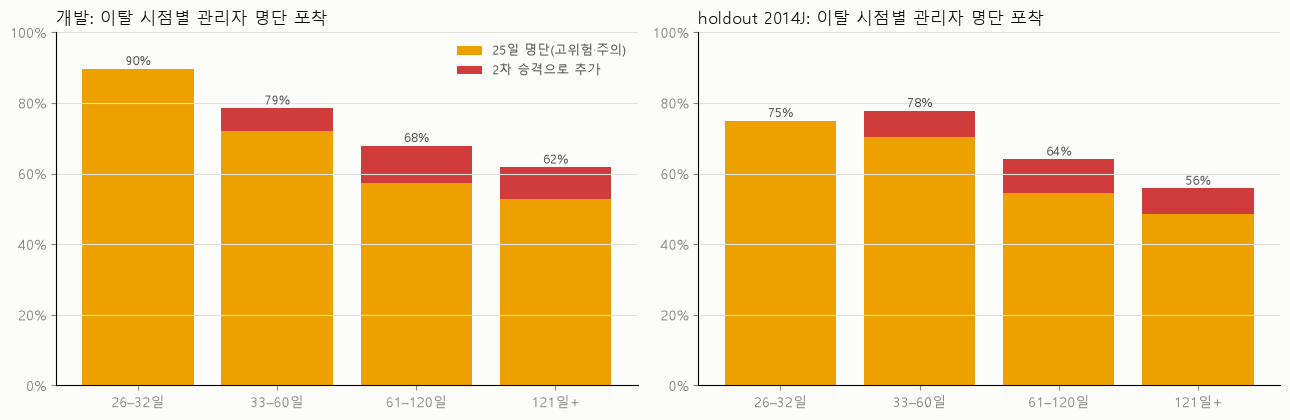

In [9]:
hold = cp[cp['세트'] == 'holdout'].reset_index(drop=True)
hold_e = hold[hold['enrolled_at_cp']]
hold_grid = hold_e.assign(신호=np.select([hold_e['missed_cp'], hold_e['activity_decline']], ['평가 미제출', '제출 + 활동 감소'], '제출 + 활동 유지')).groupby(['tier', '신호'])[TARGET].agg(['size', 'mean']).unstack('신호')
hold_grid.index = hold_grid.index.map(TIER_NAMES)
print('holdout: 체크포인트 재학생의 등급 × 신호별 이후 이탈률')
display(hold_grid.round(3))

compare = pd.DataFrame({'개발': evaluate(dev, RULES[CHOSEN](dev)), 'holdout 2014J': evaluate(hold, RULES[CHOSEN](hold))}).T
show(compare, fmt)
rule_hold = pd.DataFrame({k: evaluate(hold, f(hold)) for k, f in RULES.items()}).T
print('(사후 확인) 후보 규칙의 holdout 결과 — 규칙 선택에는 사용하지 않음')
show(rule_hold, fmt)

rows = []
for m in sorted(hold['code_module'].unique()):
    s = hold[hold['code_module'] == m].reset_index(drop=True)
    r = evaluate(s, RULES[CHOSEN](s))
    rows.append({'code_module': m, '체크포인트일': s['checkpoint_day'].iloc[0], **{k: r[k] for k in ['관리자 명단(25일)', '관리자 명단 추가', '승격 인원', '승격 집단 이탈률', '전체 이탈자 포착(25일 명단)', '전체 이탈자 포착(1차+2차)']}})
hold_mod = pd.DataFrame(rows).set_index('code_module')
show(hold_mod, {c: '{:.1%}' for c in hold_mod.columns if c not in ('승격 인원', '체크포인트일')} | {'승격 인원': '{:,.0f}', '체크포인트일': '{:.0f}'})
timing_hold = timing(hold, RULES[CHOSEN](hold))
show(timing_hold, {'이탈자': '{:,}', '명단25': '{:.1%}', '승격_추가': '{:.1%}', '1차+2차': '{:.1%}'})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, (name, t) in zip(axes, [('개발', timing_dev), ('holdout 2014J', timing_hold)]):
    x = np.arange(len(t))
    ax.bar(x, t['명단25'], color='#eda100', label='25일 명단(고위험·주의)')
    ax.bar(x, t['승격_추가'], bottom=t['명단25'], color='#d03b3b', label='2차 승격으로 추가')
    for i, (a, b) in enumerate(zip(t['명단25'], t['1차+2차'])):
        ax.text(i, b + 0.01, f'{b:.0%}', ha='center', fontsize=9)
    ax.set_xticks(x, t.index.astype(str))
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_title(f'{name}: 이탈 시점별 관리자 명단 포착', loc='left')
    ax.grid(axis='x', visible=False)
axes[0].legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

**해석 — holdout 2014J (규칙 고정 후 1회)**

- **승격 신호가 새 학기에도 유지, 오히려 더 강하다**: 관찰 × 미제출의 이후 이탈률 26.6%(개발 21.1%).
- **R1 적용 결과**

  | 지표 | 개발 | holdout |
  |---|---:|---:|
  | 관리자 명단 추가 | 7.4% | 5.4% |
  | 관리자 명단 합계 | 40.9% | 39.6% |
  | 승격 집단 이탈률 | 21.1% | **26.6%** |
  | 전체 이탈자 포착 (1차 → 1차+2차) | 61.1% → 69.3% | **56.1% → 63.8%** (+7.7%p) |

- **늦은 이탈자 보완이 확인됐다**: 61–120일 이탈자 54.4% → 64.1%, 121일 이후 48.5% → 55.8%, 33–60일 70.5% → 77.8%.
- **과목별**: GGG가 0% → 22.8%로 가장 크게 오르고 승격 적중률도 30.0%로 개발(9.9%)보다 높다(GGG 기준 이탈률 상승의 영향). EEE는 29.4% → 46.3%.
  BBB는 2014J 체크포인트가 54일로 늦고 25일 명단이 이미 44.9%라 추가가 0.8%에 그친다.
- **사후 확인(선택 변경 없음)**: holdout에서는 일반 × 미제출도 21.9%로 20%를 넘었고, R2를 적용했다면 포착률 71.5%, 적중률 24.0%였다.
  개발 세트에서는 14.0%로 기준 미달이었으므로 규칙을 바꾸지 않는다. **다음 학기 데이터가 쌓이면 일반 등급 포함 여부를 재검토할 후보**로 기록한다.

## 9. 결과 저장

| 파일 | 내용 |
|---|---|
| `second_checkpoint_rule_n25.json` | 체크포인트 정의, 승격 원칙, 채택 규칙, 개발·holdout 지표 |
| `second_checkpoint_students_n25.csv` | 학생별 체크포인트일, 재학 여부, 미제출·활동 감소, 25일 등급, 최종 관리자 상태 |
| `second_checkpoint_rule_comparison_n25.csv` | 후보 규칙 비교(개발·holdout) |

In [10]:
final_status = np.select([cp['tier'] <= 2, cp['enrolled_at_cp'] & RULES[CHOSEN](cp)], ['25일 명단', '2차 승격'], '명단 외')
cp_out = cp[GRAIN + ['세트', TARGET, 'proba', 'tier', 'checkpoint_day', 'checkpoint_type', 'checkpoint_weight', 'enrolled_at_cp', 'missed_cp', 'activity_decline', 'rate_ratio']].assign(manager_status=final_status)
cp_out.to_csv(MODEL_DIR / 'second_checkpoint_students_n25.csv', index=False, encoding='utf-8-sig')
pd.concat({'개발': rule_dev, 'holdout 2014J': rule_hold}, names=['세트', '규칙']).to_csv(MODEL_DIR / 'second_checkpoint_rule_comparison_n25.csv', encoding='utf-8-sig')


def to_py(o):
    return o.item() if hasattr(o, 'item') else str(o)


doc = {
    'created_from': 'Notebooks/03_Modeling/04_Second_Checkpoint.ipynb',
    'checkpoint_definition': '과목·학기별 25일 이후 첫 TMA/CMA 마감일(가중치 무관), 같은 날 마감 평가는 모두 대상',
    'enrolled_definition': 'date_unregistration 없음 또는 checkpoint_day 초과 (평가용으로만 사용)',
    'missed_definition': '체크포인트일까지 해당 평가를 모두 제출하지 않음, 이월(is_banked=1)은 제출로 간주',
    'activity_decline_definition': f'(25, C] 일평균 클릭 / [0, 25] 일평균 클릭 <= {DECLINE_RATIO} (25일까지 클릭 0이면 이후 클릭 0)',
    'promotion_principle': f'25일 관찰·일반 등급 중 조건 집단의 개발 세트 이후 이탈률 >= {PROMOTE_MIN_RATE} 이면 주의로 승격',
    'candidate_group_rates_dev': cand_table.to_dict(orient='index'),
    'chosen_rule': CHOSEN,
    'checkpoints': checkpoint[['code_module', 'code_presentation', 'checkpoint_day', 'checkpoint_type', 'checkpoint_weight', 'same_day_n']].to_dict(orient='records'),
    'dev': evaluate(dev, RULES[CHOSEN](dev)),
    'holdout': evaluate(hold, RULES[CHOSEN](hold)),
}
with open(MODEL_DIR / 'second_checkpoint_rule_n25.json', 'w', encoding='utf-8') as f:
    json.dump(doc, f, ensure_ascii=False, indent=2, default=to_py)
chk = pd.read_csv(MODEL_DIR / 'second_checkpoint_students_n25.csv')
assert len(chk) == 27_654 and not chk.duplicated(GRAIN).any()
print(chk['manager_status'].value_counts())

manager_status
명단 외      16452
25일 명단     9328
2차 승격      1874
Name: count, dtype: int64


## 10. 결론

### 확정한 2차 규칙

| 항목 | 내용 |
|---|---|
| 체크포인트 | 과목·학기별 25일 이후 첫 TMA/CMA 마감일 (CCC 32 / EEE 33 / BBB 40–54 / DDD 41–53 / FFF 47–52 / AAA 54 / GGG 61일) |
| 대상 | 체크포인트에도 재학 중이고 25일 등급이 **관찰**인 학생 |
| 승격 조건 | 그 평가를 체크포인트일까지 **미제출** (이월은 제출로 간주) |
| 결과 | **주의 등급으로 승격** → 관리자 명단에 추가 |
| 선정 원칙 | 승격 집단의 개발 세트 이후 이탈률 ≥ 20%(주의 하한과 같은 의미) |

### 성과

- holdout에서 관리자 명단을 **5.4%p** 늘려 전체 이탈자 포착을 **56.1% → 63.8%**로 올렸다. 승격 집단의 실제 이탈률은 **26.6%**.
- 늦게 떠나는 학생(61일 이후)의 포착이 **7–10%p** 올라, 1차 등급의 약점을 보완했다.

### 디펜스 논리

1. **왜 평가 미제출인가**: 25일 이후 클릭 변화는 같은 등급 안에서 거의 구분력이 없고(AUC 0.45–0.58), 제출하고 활동이 줄어든 학생도 이탈률이 활동을 유지한 학생과 같다. 미제출은 관찰·일반 등급에서 이탈률을 약 2배(10.2%→21.1%, 6.6%→14.0%), 고위험·주의에서 약 1.3배 올린다.
2. **왜 과목별 첫 평가 마감일인가**: 32일 고정이면 새 평가가 마감된 학생이 8.1%뿐이고, 60일 고정이면 그 전에 이탈자 28.0%가 떠난다(3.1절). 과목 일정에 맞춰야 신호가 생기는 즉시 점검할 수 있다.
3. **왜 관찰만인가**: 일반 등급 미제출자의 이탈률(14.0%)은 평균보다 낮아 명단에 올릴 근거가 없고, 포함하면 추가 인원이 두 배가 되며 적중률이 17.7%로 떨어진다. 1차 등급의 "주의 = 평균 이상"이라는 의미를 지키기 위한 선택이다.
4. **새 학기에도 통하는가**: holdout에서 승격 집단 이탈률이 26.6%로 오히려 높고, 늦은 이탈자 포착이 개선됐다.

### 한계와 재검토 항목

- **GGG**: 개발 세트에서 승격 적중률 9.9%로 원칙에 못 미치는 과목이지만 과목별 예외를 두지 않았다(holdout에서는 30.0%). GGG는 체크포인트가 61일로 늦고 평가가 가중치 0이다.
- **일반 × 미제출**: holdout에서 21.9%로 기준을 넘었다. 다음 학기 데이터로 재검토할 후보다.
- **BBB 2014J**: 체크포인트가 54일로 늦어져 2차의 추가 효과가 거의 없다(평가 일정 변화의 영향).
- 체크포인트 전 이탈자(과목별 5–31%)는 25일 명단에 있어야만 포착된다. 1차 등급이 그 역할을 한다.